## DEMO 2.1: **k-Nearest Neighbor Classification**
<u>Nội dung</u>:
1. Phân lớp IRIS
2. Phân lớp Social_Network_Ads  

<u>Cập nhật</u>: **04/2026**




---
#### **MÔI TRƯỜNG TRIỂN KHAI ỨNG DỤNG**
---

In [1]:
## Kết nối Google Drive
from google.colab import drive
drive.mount("/content/gdrive", force_remount = True)

folder = '/content/gdrive/My Drive/Edu/1. UEH/Machine Learning/1. Demo/Ch2 - Supervised Learning'

Mounted at /content/gdrive


In [2]:
## Thư viện xử lý DL
import numpy                    as np
import pandas                   as pd

## Xây dựng mô hình
import joblib                   as jlb
from   sklearn.model_selection  import train_test_split
from   sklearn.neighbors        import KNeighborsClassifier

## Biểu diễn trực quan DL
import matplotlib.pyplot        as plt
import seaborn                  as sbn

## Thư viện khác
import warnings
warnings.filterwarnings('ignore')

---
#### 1. **Phân lớp IRIS**
---

In [3]:
## Tập tin dữ liệu IRIS
data = pd.read_excel(folder + '/Data/Iris.xls')
print('** Metadata:')
print(data.info())

print('\n** Dữ liệu mẫu:')
print(data.head())

print('\n** Thống kê:')
print(data.describe())

** Metadata:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sepallength  150 non-null    float64
 1   sepalwidth   150 non-null    float64
 2   petallength  150 non-null    float64
 3   petalwidth   150 non-null    float64
 4   species      150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None

** Dữ liệu mẫu:
   sepallength  sepalwidth  petallength  petalwidth      species
0          5.1         3.5          1.4         0.2  Iris-setosa
1          4.9         3.0          1.4         0.2  Iris-setosa
2          4.7         3.2          1.3         0.2  Iris-setosa
3          4.6         3.1          1.5         0.2  Iris-setosa
4          5.0         3.6          1.4         0.2  Iris-setosa

** Thống kê:
       sepallength  sepalwidth  petallength  petalwidth
count   150.000000  150.000000   150.000000  150.000000

In [4]:
## Các features: [sepallength, sepalwidth, petallength, petalwidth]
X = data.drop('species', axis = 1)

## Biến target: [species]
y = data.species

print(pd.concat([X, y], axis = 1).head())

   sepallength  sepalwidth  petallength  petalwidth      species
0          5.1         3.5          1.4         0.2  Iris-setosa
1          4.9         3.0          1.4         0.2  Iris-setosa
2          4.7         3.2          1.3         0.2  Iris-setosa
3          4.6         3.1          1.5         0.2  Iris-setosa
4          5.0         3.6          1.4         0.2  Iris-setosa


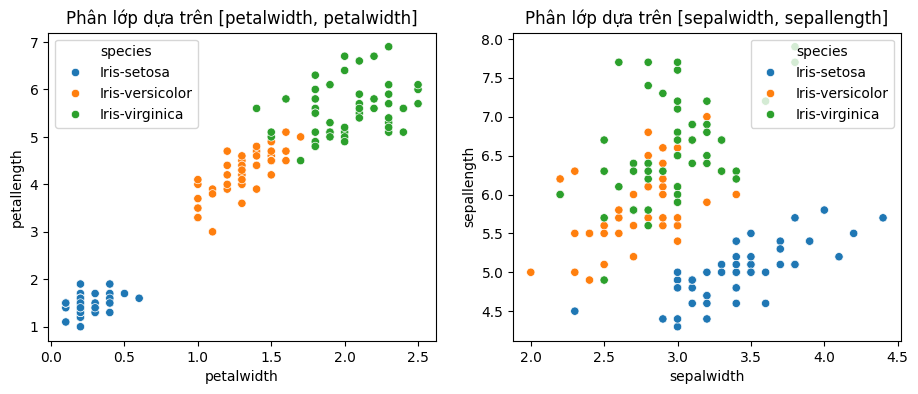

In [5]:
## Biểu diễn trực quan dữ liệu
plt.figure(figsize = (11, 4))
plt.subplot(1, 2, 1)
sbn.scatterplot(x = 'petalwidth', y = 'petallength', data = data, hue = 'species')
plt.title('Phân lớp dựa trên [petalwidth, petalwidth]', fontsize = 12)

plt.subplot(1, 2, 2)
sbn.scatterplot(x = 'sepalwidth', y = 'sepallength', data = data, hue = 'species')
plt.title('Phân lớp dựa trên [sepalwidth, sepallength]', fontsize = 12)

plt.show()

In [7]:
## Chia tập dữ liệu thành training, test sets theo tỷ lệ 70:30
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .3, random_state = 1)

In [8]:
##------------------------------------------------------------------------------
## Xây dựng mô hình kNN Classification
##------------------------------------------------------------------------------
k   = int(pow(X_train.shape[0], 1/2) / 2)  # giá trị phổ biến
knn = KNeighborsClassifier(n_neighbors = k)
knn.fit(X_train, y_train)  # huấn luyện để tạo  mô hình

KNeighborsClassifier()

In [9]:
## Lưu trữ mô hình để khai thác về sau
jlb.dump(knn, folder + '/Output/kNN_Iris.pkl')

['/content/gdrive/My Drive/Edu/1. UEH/Machine Learning/1. Demo/Ch2 - Supervised Learning/Output/kNN_Iris.pkl']

In [10]:
## Khai thác mô hình đã được huấn luyện (lưu trữ) để dự đoán
model  = jlb.load(folder + '/Output/kNN_Iris.pkl')

tiep = 'C'
while (tiep.upper() == 'C'):
    # Nhập dữ liệu
    spl    = float(eval(input(f'sepallength [4.3, 7.9]: ')))
    spw    = float(eval(input(f'sepalwidth  [2.0, 4.4]: ')))
    ptl    = float(eval(input(f'petallength [1.0, 6.9]: ')))
    ptw    = float(eval(input(f'petalwidth  [0.1, 2.5]: ')))
    X_new  = pd.DataFrame([spl, spw, ptl, ptw]).T

    # Dự đoán
    y_pred = model.predict(X_new)
    ## print(f'Mẫu [{X_new.to_string(index = False, header = False)}] được dự đoán là {y_pred}')
    print(f'\nMẫu {X_new.values[0].tolist()} được dự đoán là {y_pred}\n')

    tiep = input('Tiếp tục (C/K) ? ')

sepallength [4.3, 7.9]: 6.7
sepalwidth  [2.0, 4.4]: 1
petallength [1.0, 6.9]: 3.5
petalwidth  [0.1, 2.5]: 1.7
Mẫu [6.7, 1.0, 3.5, 1.7] được dự đoán là ['Iris-versicolor']
Tiếp tục (C/K) ? C
sepallength [4.3, 7.9]: 6.7
sepalwidth  [2.0, 4.4]: 3
petallength [1.0, 6.9]: 5
petalwidth  [0.1, 2.5]: 1.7
Mẫu [6.7, 3.0, 5.0, 1.7] được dự đoán là ['Iris-versicolor']
Tiếp tục (C/K) ? C
sepallength [4.3, 7.9]: 7.7
sepalwidth  [2.0, 4.4]: 2.6
petallength [1.0, 6.9]: 6.9
petalwidth  [0.1, 2.5]: 2.3
Mẫu [7.7, 2.6, 6.9, 2.3] được dự đoán là ['Iris-virginica']
Tiếp tục (C/K) ? C
sepallength [4.3, 7.9]: 5.2
sepalwidth  [2.0, 4.4]: 4.1
petallength [1.0, 6.9]: 1.5
petalwidth  [0.1, 2.5]: 0.1
Mẫu [5.2, 4.1, 1.5, 0.1] được dự đoán là ['Iris-setosa']
Tiếp tục (C/K) ? K


In [12]:
## Số trường hợp đoán ĐÚNG trong tập Test
df = pd.DataFrame({'yHat':model.predict(X_test), 'y': pd.Series(y_test)})
print(f'Accuracy(Test) = {len(df[df.yHat == df.y])} / {len(X_test)}')

Accuracy(Test) = 44 / 45


---
#### 2. **Phân lớp Social_Network_Ads**
---

In [13]:
## Tập tin dữ liệu Social_Network_Ads
data = pd.read_csv(folder + '/Data/Social_Network_Ads.csv')
print(data.head().to_string(index = False))

    User ID  Gender  Age  EstimatedSalary  EstimatedSalary_K  Purchased
0  15624510    Male   19            19000                 19          0
1  15810944    Male   35            20000                 20          0
2  15668575  Female   26            43000                 43          0
3  15603246  Female   27            57000                 57          0
4  15804002    Male   19            76000                 76          0


In [30]:
## Các features: [Gender, Age, EstimatedSalary]
X = data.drop(['User ID', 'EstimatedSalary_K', 'Purchased'], axis = 1)
X.head()

## Biến target: Purchased
y = data.Purchased

print(pd.concat([X, y], axis = 1).head().to_string(index = False))

Gender  Age  EstimatedSalary  Purchased
  Male   19            19000          0
  Male   35            20000          0
Female   26            43000          0
Female   27            57000          0
  Male   19            76000          0


In [21]:
## Chuyển Gender thành kiểu Numerical
sex       = {'Male':1, 'Female':0}
X['Male'] = [sex[i] for i in data.Gender]
X         = X.drop(['Gender'], axis = 1)

print(pd.concat([X, y], axis = 1).head().to_string(index = False))

 Age  EstimatedSalary  Male  Purchased
  19            19000     1          0
  35            20000     1          0
  26            43000     0          0
  27            57000     0          0
  19            76000     1          0


In [22]:
## Chia tập dữ liệu thành training, test sets theo tỷ lệ 70:30
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .3)

In [23]:
##------------------------------------------------------------------------------
## Xây dựng mô hình kNN Classification
##------------------------------------------------------------------------------
k   = int(pow(X_train.shape[0], 1/2) / 2)  # giá trị phổ biến
print(f'Giá tri k = {k}')
knn = KNeighborsClassifier(n_neighbors = k)
knn.fit(X_train, y_train)  # huấn luyện để tạo  mô hình

Giá tri k = 8


KNeighborsClassifier(n_neighbors=8)

In [24]:
## Lưu trữ mô hình để khai thác về sau
jlb.dump(knn, folder + '/Output/kNN_Social_Network_Ads.pkl')

['/content/gdrive/My Drive/Edu/1. UEH/Machine Learning/1. Demo/Ch2 - Supervised Learning/Output/kNN_Social_Network_Ads.pkl']

In [31]:
## Khai thác mô hình đã được huấn luyện để đoán (Test set)
model  = jlb.load(folder + '/Output/kNN_Social_Network_Ads.pkl')

tiep   = 'C'
labels = np.array(['KHÔNG mua', 'MUA'])
while (tiep.upper() == 'C'):
    # Nhập dữ liệu
    age    = int(eval(input('Age    [18, 60]:           ')))
    salary = int(eval(input('Salary [15000, 150000]:    ')))
    gender = int(eval(input('Gender {1-Male, 0-Female}: ')))
    X_new  = pd.DataFrame([age, salary, gender]).T

    # Dự đoán
    y_pred = 'Purchase = Yes' if model.predict(X_new) == 1 else 'Purchase = No'
    print(f'\nMẫu {X_new.values[0].tolist()} được dự đoán là {y_pred}\n')

    tiep = input('Tiếp tục (C/K) ? ')

Age    [18, 60]:           20
Salary [15000, 150000]:    30000
Gender {1-Male, 0-Female}: 0

Mẫu [20, 30000, 0] được dự đoán là Purchase = No
Tiếp tục (C/K) ? K


In [32]:
## Số trường hợp đoán ĐÚNG trong tập Test
df = pd.DataFrame({'yHat':model.predict(X_test), 'y': pd.Series(y_test)})
print(f'Accuracy(Test) = {len(df[df.yHat == df.y])} / {len(X_test)}')

Accuracy(Test) = 90 / 120
